# Logistic Regression from Scratch

**Jordan Kim**

This notebook implements binary logistic regression in NumPy and trains it on a university admission dataset (two exam scores → admit / not admit). The workflow covers data exploration, model definition, gradient descent training, and evaluation.

References: [Andrew Ng — Logistic Regression (ex2)](http://socialmedia-class.org/slides/AndrewNg_ex2.pdf)


## Setup

Import NumPy and Matplotlib for numerics and plotting.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

for base in (Path.cwd(), Path.cwd().parent):
    candidate = base / "data" / "data.txt"
    if candidate.exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError("Could not find data/data.txt relative to the working directory.")

print(f"Python {sys.version.split()[0]}")
print(f"Data: {DATA_PATH.resolve()}")


Python 3.12.7
Data: C:\sProjects\ml-test-project\data\data.txt


## Explore the data

The dataset has exam scores for 100 applicants and whether each was admitted.


# training examples: 100
# features: 2


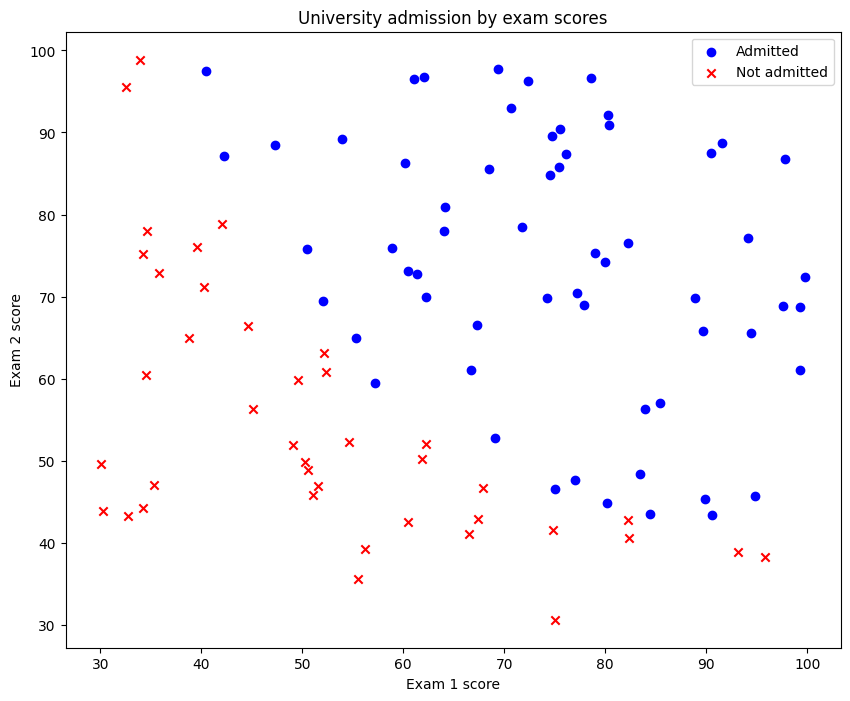

In [2]:
data = np.loadtxt(DATA_PATH, delimiter=",")

train_X = data[:, 0:2]
train_y = data[:, 2]

m_samples, n_features = train_X.shape
print("# training examples:", m_samples)
print("# features:", n_features)

pos = train_y == 1
neg = train_y == 0
plt.scatter(train_X[pos, 0], train_X[pos, 1], marker="o", c="b", label="Admitted")
plt.scatter(train_X[neg, 0], train_X[neg, 1], marker="x", c="r", label="Not admitted")
plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.legend()
plt.title("University admission by exam scores")
plt.show()


## Model components

Sigmoid: $\sigma(z) = \frac{1}{1 + e^{-z}}$

Binary cross-entropy cost and gradient for logistic regression, implemented with vectorized NumPy operations.


In [3]:
def sigmoid(z):
    """Element-wise sigmoid."""
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def cost_function(theta, X, y):
    """Average binary cross-entropy."""
    h = sigmoid(X @ theta)
    epsilon = 1e-10
    h = np.clip(h, epsilon, 1 - epsilon)
    m = X.shape[0]
    return (-1 / m) * (y @ np.log(h) + (1 - y) @ np.log(1 - h))


def gradient_update(theta, X, y):
    """Gradient of the cost with respect to theta."""
    h = sigmoid(X @ theta)
    m = X.shape[0]
    return (1 / m) * (X.T @ (h - y))


z = np.array([[1, 2], [-1, -2]])
print("sigmoid(z):\n", sigmoid(z))

t_X = np.array([[1, 2], [-1, -2]])
t_y = np.array([0, 1])
print("cost (theta=[-10,10]):", cost_function(np.array([-10, 10]), t_X, t_y))
print("cost (theta=[10,-10]):", cost_function(np.array([10, -10]), t_X, t_y))


sigmoid(z):
 [[0.73105858 0.88079708]
 [0.26894142 0.11920292]]
cost (theta=[-10,10]): 10.000045398899701
cost (theta=[10,-10]): 4.539889921682063e-05


## Gradient check

Compare the analytic gradient to a numerical estimate via SciPy.


In [4]:
from scipy import optimize

rng = np.random.default_rng(42)
t_samples, t_features = 100, 10
t_X = rng.standard_normal((t_samples, t_features))
t_y = rng.integers(0, 2, size=t_samples)
t_theta = rng.standard_normal(t_features)

print("check_grad:", optimize.check_grad(cost_function, gradient_update, t_theta, t_X, t_y))


check_grad: 6.528977765488304e-08


## Training

Batch gradient descent with an intercept (bias) term. The decision boundary is plotted periodically during optimization.


[iteration      1] cost = 13.815511


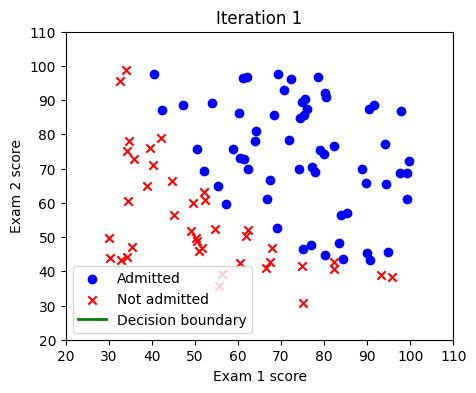

[iteration  10000] cost = 0.568445


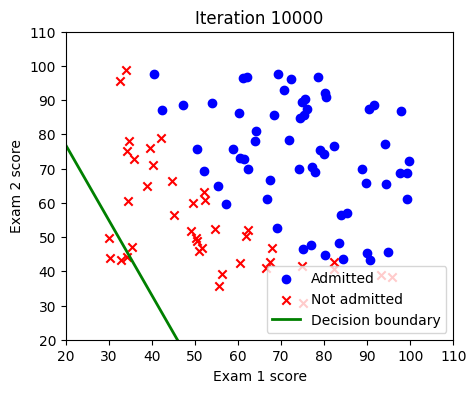

[iteration  20000] cost = 0.533296


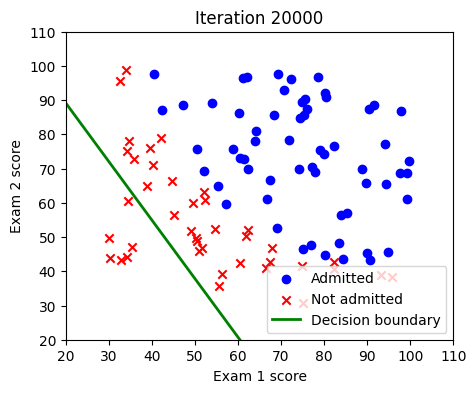

[iteration  30000] cost = 0.503525


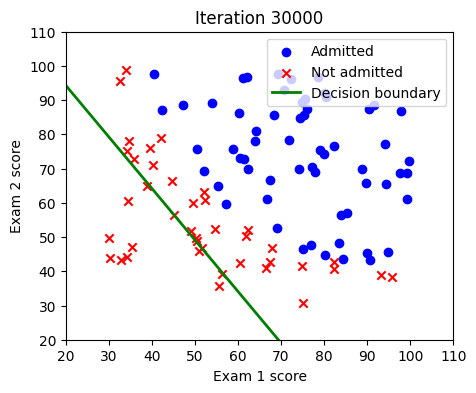

[iteration  40000] cost = 0.478154


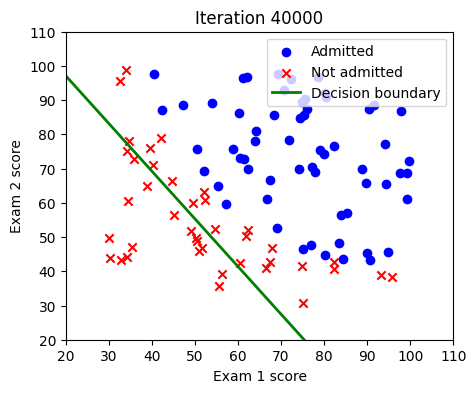

[iteration  50000] cost = 0.456383


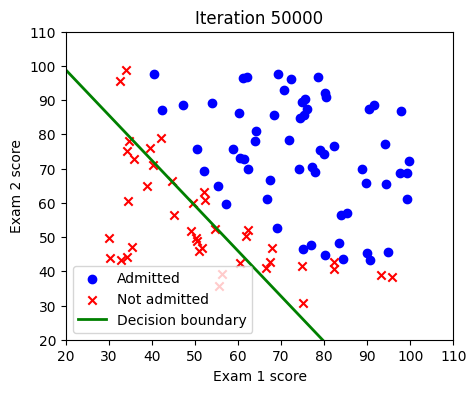

[iteration  60000] cost = 0.437562


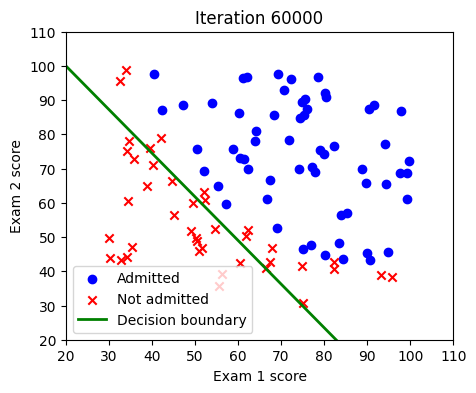

[iteration  70000] cost = 0.421173


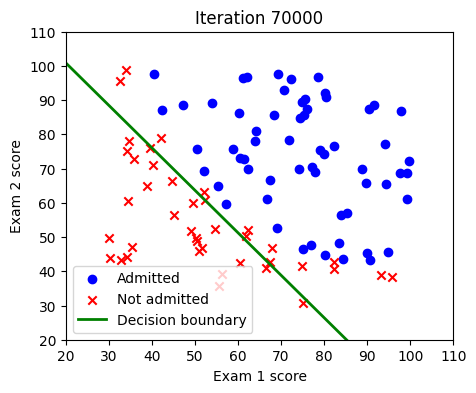

[iteration  80000] cost = 0.406798


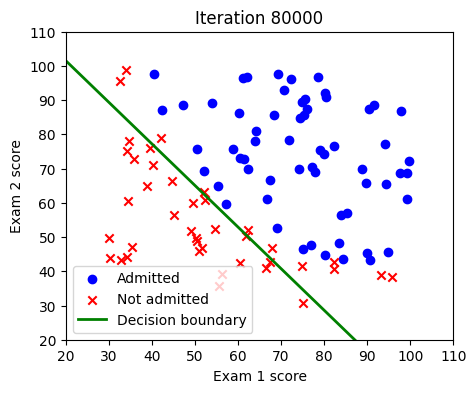

[iteration  90000] cost = 0.394104


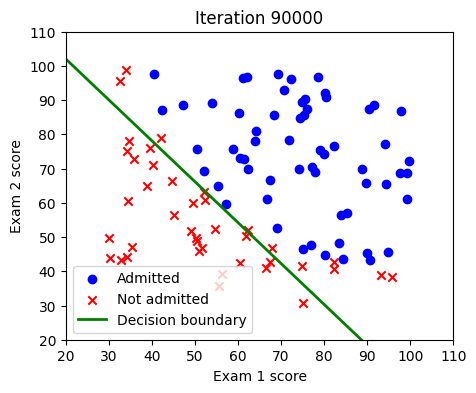

[iteration 100000] cost = 0.382823


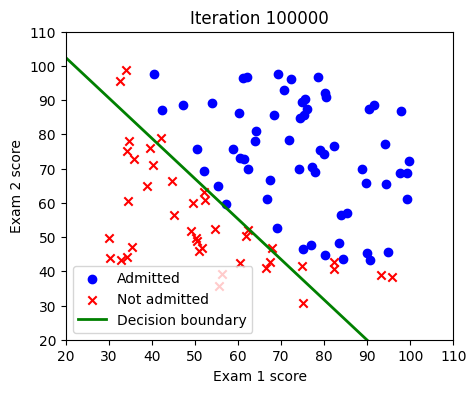

In [5]:
def gradient_descent(theta, X, y, alpha, max_iterations, print_iterations):
    """Batch gradient descent with periodic decision-boundary plots."""
    alpha *= m_samples
    iteration = 0
    X = np.c_[np.ones(X.shape[0]), X]

    while iteration < max_iterations:
        iteration += 1
        grad = gradient_update(theta, X, y)
        theta = theta - alpha * grad

        if iteration % print_iterations == 0 or iteration == 1:
            cost = cost_function(theta, X, y)
            print(f"[iteration {iteration:>6}] cost = {cost:.6f}")

            plt.figure(figsize=(5, 4))
            plt.xlim(20, 110)
            plt.ylim(20, 110)
            plt.scatter(X[y == 1, 1], X[y == 1, 2], marker="o", c="b", label="Admitted")
            plt.scatter(X[y == 0, 1], X[y == 0, 2], marker="x", c="r", label="Not admitted")
            plt.xlabel("Exam 1 score")
            plt.ylabel("Exam 2 score")
            t = np.arange(10, 100, 0.1)
            boundary = -(theta[0] + t * theta[1]) / theta[2]
            plt.plot(t, boundary, "g-", linewidth=2, label="Decision boundary")
            plt.legend()
            plt.title(f"Iteration {iteration}")
            plt.show()

    return theta


initial_theta = np.random.randn(3)
alpha = 1e-5
max_iter = 100_000
print_every = 10_000

learned_theta = gradient_descent(initial_theta, train_X, train_y, alpha, max_iter, print_every)


## Predictions

Classify new applicants and report training accuracy.


In [6]:
def predict(theta, X):
    """Return probabilities and 0/1 labels for raw features (no bias column)."""
    X_bias = np.c_[np.ones(X.shape[0]), X]
    probabilities = sigmoid(X_bias @ theta)
    labels = (probabilities >= 0.5).astype(int)
    return probabilities, labels


examples = [
    ("Strong candidate", np.array([[90, 90]])),
    ("Borderline", np.array([[50, 60]])),
    ("Weak candidate", np.array([[10, 50]])),
]

for name, X in examples:
    prob, label = predict(learned_theta, X)
    admitted = "admitted" if label[0] == 1 else "not admitted"
    print(f"{name}: P(admit)={prob[0]:.3f} -> {admitted}")

_, train_labels = predict(learned_theta, train_X)
accuracy = 100 * np.mean(train_labels == train_y)
print(f"\nTraining accuracy: {accuracy:.2f}%")


Strong candidate: P(admit)=0.940 -> admitted
Borderline: P(admit)=0.431 -> not admitted
Weak candidate: P(admit)=0.074 -> not admitted

Training accuracy: 91.00%
